# Wavefront sensor mechanical testing data acqusition
awojdyla@lb.gov, Sept 2024

import necessary packages
(if there is an issue, do !pip instal package and restart the kernel)

In [7]:
import numpy as np
from pypylon import pylon

## camera controls

### connecting to the camera

In [2]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())
#camera ip is 192.168.10.70
# a2A1920-51gcBAS 1920x1080, 3.45 um pixel size
px_m = 3.45
#distance to camera 150 mm
d_m = 0.15

### grabbing an image

In [4]:
timeoutMs = 1000
img = camera.GrabOne(timeoutMs)

### releasing the camera

In [5]:
camera.Close()

### translating the camera signal into a matrix

In [6]:
img_np = np.array(img.Array)

### displaying the data

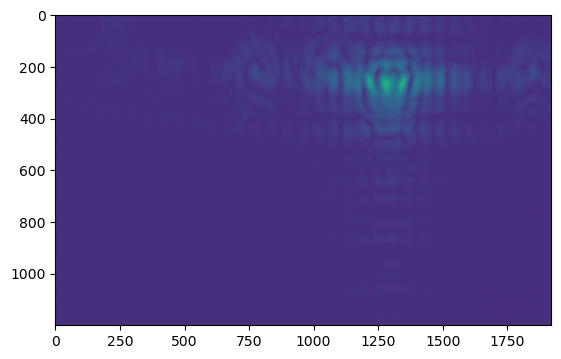

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img_np)
plt.show()

## processing the data

### thresholding to remove ambiant light

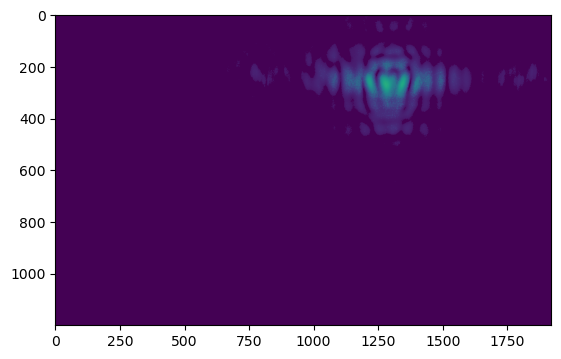

In [8]:
img_thr = img_np
img_thr[img_thr<60] = 0
plt.imshow(img_thr)
plt.show()

### extracting beam data

In [9]:
def beam_stat_px(x, y):
    I = np.abs(y **2)/np.max(np.abs(y **2))
    mu_px = np.sum(x * y)/np.sum(y)
    sigma_px= np.sqrt(np.sum((x - mu_px)**2 * y)/np.sum(y))
    return(mu_px, sigma_px)

In [10]:
Ix = np.sum(img_thr,axis=0)
Iy = np.sum(img_thr,axis=1)

In [11]:
Nx = np.shape(Ix)[0]
Ny = np.shape(Iy)[0]
x_px=np.arange(Nx)
y_px=np.arange(Ny)

(mux_px, sigmax_px) = beam_stat_px(x_px, Ix)
(muy_px, sigmay_px) = beam_stat_px(y_px, Iy)

print('horizontal centroid is at %1.2f px' % mux_px)
print('vertical centroid is at %1.2f px' % muy_px)


horizontal centroid is at 1289.53 px
vertical centroid is at 262.69 px


### static data acquisition over ~3h

DO NOT RUN ! VERY LONG

In [124]:
import time
Nt = 10000 # about 10000 since settle time is 1sec
xx = np.zeros(Nt)
yy = np.zeros(Nt)
for i_t in np.arange(Nt):
    time.sleep(1)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<50] = 0
    Ix = np.sum(img_thr,axis=0)
    Iy = np.sum(img_thr,axis=1)
    Nx = np.shape(Ix)[0]
    Ny = np.shape(Iy)[0]
    x_px=np.arange(Nx)
    y_px=np.arange(Ny)
    (mux_px, sigmax_px) = beam_stat_px(x_px, Ix)
    (muy_px, sigmay_px) = beam_stat_px(y_px, Iy)
    xx[i_t]= mux_px
    yy[i_t]= muy_px
    #print(i_t)

    filename = 'xx.npz'

    f = open('xx.npz', 'wb')
    np.save(f, xx)
    f.close()

    f = open('yy.npz', 'wb')
    np.save(f, yy)
    f.close()

### display data

In [12]:
plt.plot(xx)

plt.xlabel('time [sec]')
plt.ylabel('horizontal centroid [px]')
plt.show()

NameError: name 'xx' is not defined

In [13]:
plt.plot(yy)

plt.xlabel('time [sec]')
plt.ylabel('vertical centroid [px]')
plt.show()

NameError: name 'yy' is not defined

## Connecting to the stages
make sure labview is running

In [1]:
import sys
# location of a berkeley lab specific python  to reac labview through tcp port
sys.path.append("C:\\Users\\lbnl-guest\\python")
import bcs_tcp

### connection to the stages

In [3]:
(host_ip_addr, host_port, host_timeout) = ('localhost',55000,5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

In [5]:
#Raw data access -- please avoid, for debugging only
pos = bcs.GetMotorPos('Galil x.20 B')
print(pos)


0.000000



In [6]:
bcs.MoveMotor('Galil x.20 B', 1)

'Move Started\r\n'

### identifier strings

In [17]:
# linear stage
bcs_id_linear = 'Galil x.62 A'
# rotary stage
bcs_id_rotary = 'Gx.62 B - Nanotec'

### reading current position

In [18]:
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is -25.5 mm


In [19]:
str_pos_rot_rev = bcs.GetMotorPos(bcs_id_rotary)
pos_rot_rev= float(str_pos_rot_rev.rstrip())

print('rotary stage position is %1.1f rev (1/360deg)' %pos_rot_rev)
print('rotary stage position is %1.1f deg ' %(pos_rot_rev*360))

rotary stage position is -0.8 rev (1/360deg)
rotary stage position is -287.0 deg 


In [20]:
# dangerous (no soft limits)
#bcs.MoveMotor(bcs_id_linear, -10)

In [21]:
# ok for debugging, but avoid
#bcs.MoveMotor(bcs_id_rotary, 1)

### useful function for moving the stage
Adding soft limits for the linear stage, to avoid crash
# IMPORTANT

In [22]:
def GetPos(name):
    pos_str = bcs.GetMotorPos(name)
    pos_ct = int(float(pos_str.rstrip()))
    return pos_ct
GetPos(bcs_id_linear)

def GetStatus(name):
    stat = bcs.GetMotorStat(name)
    #if self.verbose:
    #    print(name+" Status = " + stat)
    return ((stat[5] == "f") or (stat[5] == "F"))   # should this be 'F'??? Oh well, check for both
GetStatus(bcs_id_linear)
print('linear stage status: %i' %GetStatus(bcs_id_linear))

#hard coded limits
def GetLimits(name):
    if (name == bcs_id_linear):
        ####### HERE ###########
        lim = (-40, -3) #change me as needed
        ########################
    if (name == bcs_id_rotary):
        lim = (-10, 10)
    return lim
GetLimits(bcs_id_linear)


linear stage status: 1


(-40, -3)

In [23]:
def Move(name, pos_ct):
    #print("Starting a move from %i " % pos + " to %i" % pos_ct + " time %10.3f " % (time.time() % 100))
    lim = GetLimits(name)  # Sofware limits. this is a tuple (limit0, limit1)
    p1 = np.max((lim[0], pos_ct))
    p = np.min((p1, lim[1]))  # bound it to the limits
    
    if (pos_ct > lim[1]): print("Move: "+name+" was constrained to the upper limit")
    if (pos_ct < lim[0]): print("Move: "+name+" was constrained to the lower limit")
    
        # the time-out clock starts when we see that it is no longer moving.
    time_allowed = 5.0           # Fail after 7 seconds of no motion.
    t_check_delay = 0.1          # Don't check more often than than
    moving_tolerance = 10        # If position difference is below this, then we're not moving much.
    t_last = time.time()         # Used for the total time.
    t_timeout_start = t_last
    pos_last = GetPos(name)
    bcs.MoveMotor(name, p)  # Launch the move ********** Now we watch

    #some issue with linear motor status (returns False even after a move)

    # move_is_not_done = True
    # while move_is_not_done:
    #     tnow = time.time()
    #     if ((tnow - t_last) > t_check_delay):  # It's been long enough, we can check
    #         status = GetStatus(name)        # Check: are we done?
    #         if status:
    #             move_is_not_done = False  # this will end the loop. Great!
    #         else:
    #             pos_now = GetPos(name)
    #             tnow = time.time()
    #             if (pos_now - pos_last) >= moving_tolerance:  # we still moving, not done
    #                 t_timeout_start = tnow  # advance this clock to represent the last time we know it was moving
    #                 pos_last = pos_now      # advance the last known position
    #             else:                                         # We must be slowing down to stop
    #                 if (tnow - t_timeout_start) > time_allowed:
    #                     print("    " + name + " Move timed out...")
    #                     move_is_not_done = False  # this will end the loop. Sad.   

In [24]:
# testing the linear stage
# Move(bcs_id_linear, -10)

### wrapping the centroid analysis a little better

In [25]:
def GetCentroid(img_thr):
    Ix = np.sum(img_thr,axis=0)
    Iy = np.sum(img_thr,axis=1)
    Nx = np.shape(Ix)[0]
    Ny = np.shape(Iy)[0]
    x_px=np.arange(Nx)
    y_px=np.arange(Ny)
    (mux_px, sigmax_px) = beam_stat_px(x_px, Ix)
    (muy_px, sigmay_px) = beam_stat_px(y_px, Iy)
    return (mux_px, muy_px)

### make sure there is signal on the camera

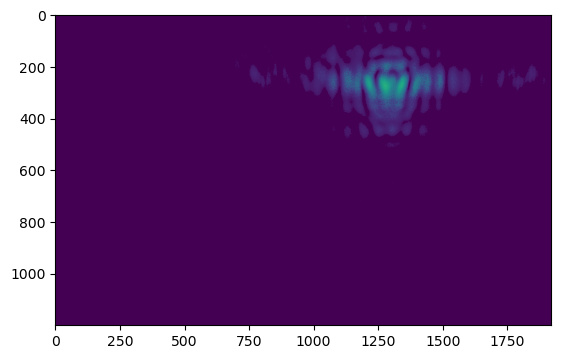

In [26]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())


img_np = np.array(camera.GrabOne(timeoutMs).Array)
img_thr = img_np
img_thr[img_thr<60] = 0
(mux_px, muy_px) = GetCentroid(img_thr)
plt.imshow(img_thr)
plt.show()

camera.Close()

## Scan the linear stage

In [27]:
# open the camer

camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())

import time

# number of point to scan 
Nt = 200

# range of motion
lin_pos_array_mm = np.linspace(-33,-7,Nt)
xx_lin_px = np.zeros(Nt)
yy_lin_px = np.zeros(Nt)

# move to first position
Move(bcs_id_linear, lin_pos_array_mm[0])
#settle time
time.sleep(10)

# start scanning
for i_t in np.arange(Nt):
    Move(bcs_id_linear, lin_pos_array_mm[i_t])
    time.sleep(1)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<60] = 0
    (mux_px, muy_px) = GetCentroid(img_thr)
    xx_lin_px[i_t]= mux_px
    yy_lin_px[i_t]= muy_px

    filename1 = 'xx_lin_px.npz'
    filename2 = 'yy_lin_px.npz'
    filename3 = 'lin_pos_array_mm.npz'

    f1 = open(filename1, 'wb')
    f2 = open(filename2, 'wb')
    f3 = open(filename3, 'wb')
    np.save(f1, xx_lin_px)
    np.save(f2, yy_lin_px)
    np.save(f3, lin_pos_array_mm)
    f1.close()
    f2.close()
    f3.close()

camera.Close()

### display data

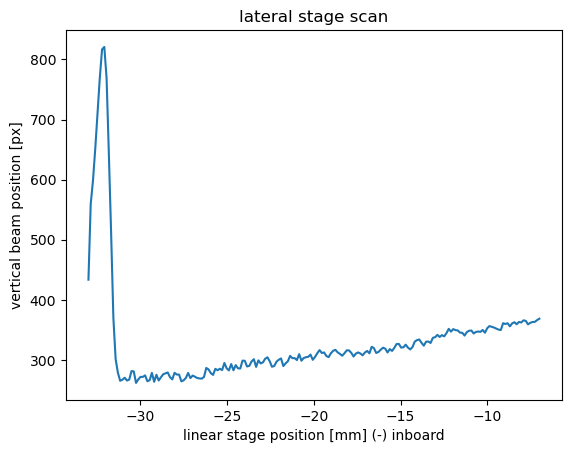

In [28]:
plt.plot(lin_pos_array_mm,yy_lin_px)
plt.xlabel('linear stage position [mm] (-) inboard')
plt.ylabel('vertical beam position [px]')
plt.title('lateral stage scan')
plt.show()

## rotary stage scan

In [29]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())

# apex position
apex_rev = -0.7973  
# number of points to scan around the apex
Nt = 40
# step size
step_rev = 0.1*1/360 # 0.1deg

rot_pos_array_rev = np.zeros(Nt)
xx_rot_px = np.zeros(Nt)
yy_rot_px = np.zeros(Nt)

import time
# move to initial position
for i_t in range(Nt):
    rot_pos_array_rev[i_t] = apex_rev + (i_t-Nt/2)*step_rev
    Move(bcs_id_rotary, rot_pos_array_rev[i_t])

    time.sleep(1)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<60] = 0
    (mux_px, muy_px) = GetCentroid(img_thr)
    xx_rot_px[i_t]= mux_px
    yy_rot_px[i_t]= muy_px
    #print(i_t)

    filename1 = 'xx_rot_px.npz'
    filename2 = 'yy_rot_px.npz'
    filename3 = 'rot_pos_array_rev.npz'

    f1 = open(filename1, 'wb')
    f2 = open(filename2, 'wb')
    f3 = open(filename3, 'wb')
    np.save(f1, xx_rot_px)
    np.save(f2, yy_rot_px)
    np.save(f3, rot_pos_array_rev)
    f1.close()
    f2.close()
    f3.close()

camera.Close()

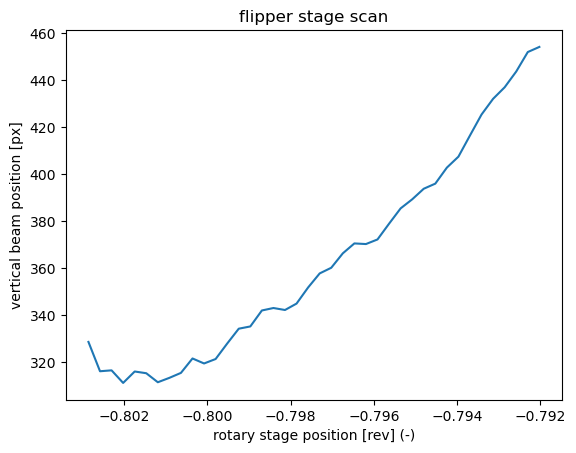

In [31]:
plt.plot(rot_pos_array_rev,yy_rot_px)
plt.xlabel('rotary stage position [rev] (-)')
plt.ylabel('vertical beam position [px]')
plt.title('flipper stage scan')
plt.show()

In [32]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())

# apex position
apex_rev = 0.5095
# number of points to scan around the apex
Nt = 20
# step size
step_rev = 0.03

rot_posrep_array_rev = np.zeros(Nt)
xx_rotrep_px = np.zeros(Nt)
yy_rotrep_px = np.zeros(Nt)

import time
# move to initial position
for i_t in range(Nt):
    rot_posrep_array_rev[i_t] = apex_rev + step_rev*np.mod(i_t,2)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)

    time.sleep(3)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<60] = 0
    (mux_px, muy_px) = GetCentroid(img_thr)
    xx_rotrep_px[i_t]= mux_px
    yy_rotrep_px[i_t]= muy_px
    #print(i_t)



    filename1 = 'xx_rot_px.npz'
    filename2 = 'yy_rot_px.npz'
    filename3 = 'rot_pos_array_rev.npz'

    f1 = open(filename1, 'wb')
    f2 = open(filename2, 'wb')
    f3 = open(filename3, 'wb')
    np.save(f1, xx_rotrep_px)
    np.save(f2, yy_rotrep_px)
    np.save(f3, rot_posrep_array_rev)
    f1.close()
    f2.close()
    f3.close()

camera.Close()

C:\Users\lbnl-guest\AppData\Local\Temp\ipykernel_2008\1232522220.py:2: RuntimeWarning: invalid value encountered in divide
  I = np.abs(y **2)/np.max(np.abs(y **2))
C:\Users\lbnl-guest\AppData\Local\Temp\ipykernel_2008\1232522220.py:3: RuntimeWarning: invalid value encountered in scalar divide
  mu_px = np.sum(x * y)/np.sum(y)


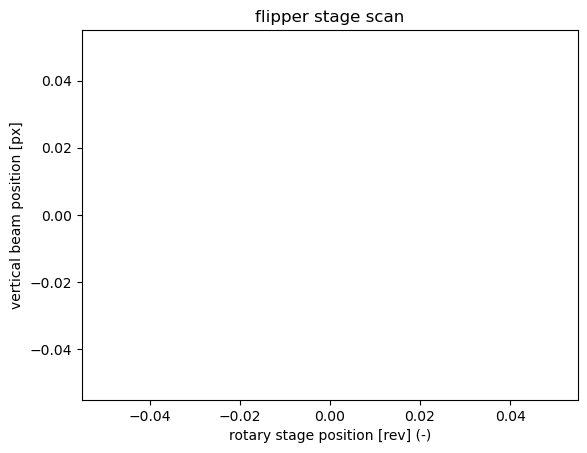

In [34]:
plt.plot(yy_rotrep_px)
plt.xlabel('rotary stage position [rev] (-)')
plt.ylabel('vertical beam position [px]')
plt.title('flipper stage scan')
plt.show()